In [35]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [36]:
# with open("./output_files/couples_new.json") as json_file:
#     couples = json.load(json_file)

# with open("./output_files/compare/Melan.A/che_phy.json") as json_file:
#     couples_by_che = json.load(json_file)

# with open("./output_files/compare/Melan.A/leve.json") as json_file:
#     couples_by_lev = json.load(json_file)

with open("./output_files/tests/cdr3/test_full.json") as json_file:
    couples = json.load(json_file)

# couples = couples_by_che

In [37]:
max_neig = 1
# Create a graph
G = nx.Graph()

# Add edges to the graph based on the dictionary
for node, neighbors in couples.items():
    count = 0
    for neighbor, weight in neighbors:
        if count < max_neig:
            G.add_edge(node, neighbor, weight=weight)
            count += 1

In [38]:
def get_edges_colors(G):
    # color edegs according to their connection, the greener the color the stringer the connection
    # Create a colormap ranging from red to green
    cmap = plt.cm.RdYlGn_r

    # Find the maximum and minimum weights
    max_weight = max([d['weight'] for _, _, d in G.edges(data=True)])
    min_weight = min([d['weight'] for _, _, d in G.edges(data=True)])

    # Normalize the weights
    norm = mcolors.Normalize(vmin=min_weight, vmax=max_weight)

    # Create a color mapping based on edge weights
    edge_colors = [cmap(norm(d['weight'])) for _, _, d in G.edges(data=True)]
    return edge_colors
    

### Visualize the whole graph

### Highest degree node

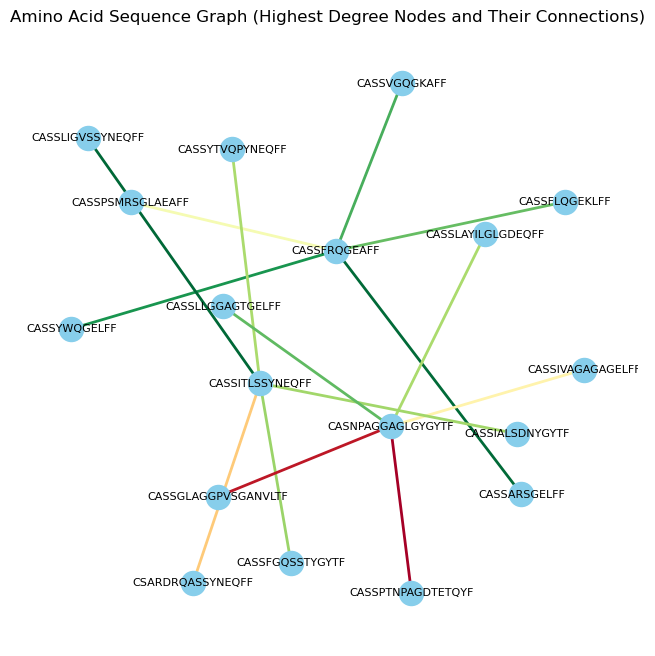

In [40]:
max_degree = max(dict(G.degree()).values())
highest_degree_nodes = [node for node, degree in dict(G.degree()).items() if degree == max_degree]

# Create a subgraph with only the highest degree nodes and their neighbors
highest_degree_neighbors = set()
for node in highest_degree_nodes:
    highest_degree_neighbors.update(G.neighbors(node))
highest_degree_neighbors.update(highest_degree_nodes)
H = G.subgraph(highest_degree_neighbors)

edge_colors = get_edges_colors(H)

# Visualize the graph
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(H, k=0.3, iterations=20)
nx.draw_networkx_nodes(H, pos, node_size=300, node_color='skyblue')
nx.draw_networkx_edges(H, pos, edge_color=edge_colors, width=2)
nx.draw_networkx_labels(H, pos, font_size=8)

# # Draw edge labels with three numbers after the decimal point
# edge_labels = {(u, v): f"{d['weight']:.3f}" for u, v, d in H.edges(data=True)}
# nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_color='black')

plt.title('Amino Acid Sequence Graph (Highest Degree Nodes and Their Connections)')
plt.axis('off')  # Turn off axis
plt.savefig('degree.png')
plt.show()


### Longest path

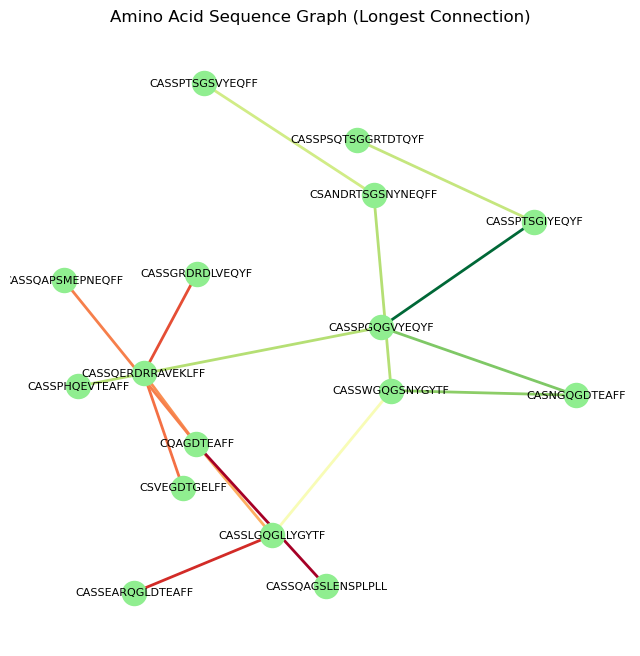

In [41]:
# Find the longest path in the graph
longest_path = max(nx.all_pairs_shortest_path_length(G), key=lambda x: max(x[1].values()))

# Extract nodes involved in the longest path
longest_path_nodes = longest_path[1].keys()

# Create a subgraph with nodes involved in the longest path
H = G.subgraph(longest_path_nodes)

edge_colors = get_edges_colors(H)


# Visualize the graph
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(H, k=0.3, iterations=20)
nx.draw_networkx_nodes(H, pos, node_size=300, node_color='lightgreen')
nx.draw_networkx_edges(H, pos, edge_color=edge_colors, width=2)
nx.draw_networkx_labels(H, pos, font_size=8)

# # Draw edge labels with three numbers after the decimal point
# edge_labels = {(u, v): f"{d['weight']:.3f}" for u, v, d in H.edges(data=True)}
# nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_color='black')


plt.title('Amino Acid Sequence Graph (Longest Connection)')
plt.axis('off')  # Turn off axis
plt.savefig('longest_path.png')
plt.show()

### Strongest Connection

### Biggest Cluster

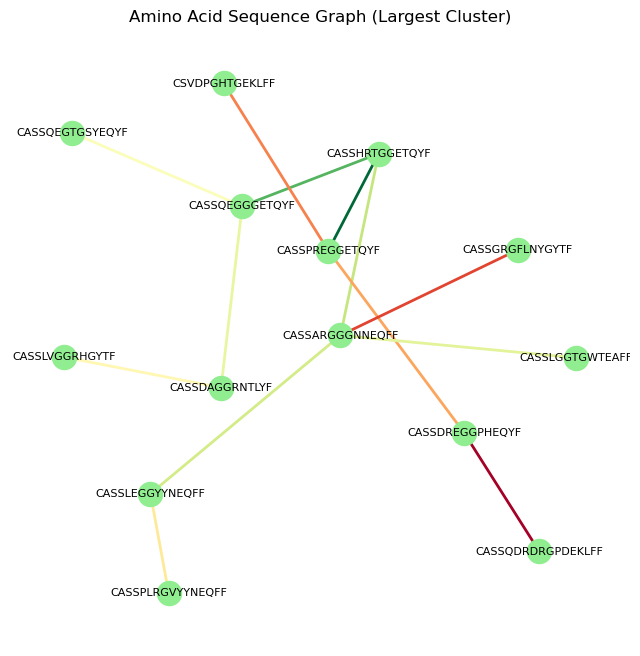

In [42]:

# Find all connected components
connected_components = list(nx.connected_components(G))

# Find the largest connected component
largest_component = max(connected_components, key=len)

# Find nth largest connected component
n = 2
largest_component = sorted(nx.connected_components(G), key=len, reverse=True)[n-1]



# Create a subgraph with nodes in the largest connected component
H = G.subgraph(largest_component)

edge_colors = get_edges_colors(H)

# Visualize the largest cluster
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(H, k=0.3, iterations=20)
nx.draw_networkx_nodes(H, pos, node_size=300, node_color='lightgreen')
nx.draw_networkx_edges(H, pos, edge_color=edge_colors, width=2)
nx.draw_networkx_labels(H, pos, font_size=8)


plt.title('Amino Acid Sequence Graph (Largest Cluster)')
plt.axis('off')  # Turn off axis
plt.savefig('largest_cluster.png')
plt.show()


In [43]:

# Find connected components
clusters = list(nx.connected_components(G))

# Create a dictionary to map sequences to cluster numbers
cluster_dict = {}
for cluster_number, cluster in enumerate(clusters):
    for sequence in cluster:
        cluster_dict[sequence] = cluster_number

# Print the cluster dictionary
cluster_dict

{'CASSQNSVGSYNEQFF': 0,
 'CASSIDAGSNYEQYF': 0,
 'CASSPTLVTSGNTIYF': 0,
 'CASSLDPGDTGELFF': 0,
 'CASSLWSAGVHNEQFF': 0,
 'CASSLASPGHFTGELFF': 0,
 'CASSFDPGSYGYTF': 0,
 'CATSIDRGREKLFF': 1,
 'CASSLSRGWTEAFF': 1,
 'CASSQDKTTGELFF': 1,
 'CASSSRDRGLGTEAFF': 1,
 'CASSWDRGTGEQYF': 1,
 'CASSFDRGTGNTIYF': 1,
 'CASSYQTGASYGYTF': 2,
 'CASSYQTGAAYGYTF': 2,
 'CASSFQTGASYGYTF': 2,
 'CASSWRTGNSGELFF': 2,
 'CASSPKTGASYGYTF': 2,
 'CASSTRGGGDAKNIQYF': 3,
 'CASRRPGGDTEAFF': 3,
 'CAAGTRTDTQYF': 3,
 'CASRRQGTVYEQYF': 3,
 'CASRGTGGGSGQPQHF': 3,
 'CASTAQGFSNQPQHF': 3,
 'CASRGQGFSYEQYF': 3,
 'CSARRSDRVNTEAFF': 3,
 'CASSTLQGADQPQHF': 4,
 'CASSIQQGADTQYF': 4,
 'CASSESGAGELFF': 5,
 'CASSIFGQREQYF': 5,
 'CASSSIAGRGEKLFF': 5,
 'CASSKQGGNIQYF': 5,
 'CASSSRTGDQETQYF': 5,
 'CASSIVGGNEQFF': 5,
 'CASSFLGLNEQFF': 5,
 'CASSIVERAEAFF': 5,
 'CASSPTPGDPHYGYTF': 6,
 'CASKGQGARDGYTF': 6,
 'CASSNFLGQGDEKLFF': 6,
 'CASSRGQGPGQETQYF': 6,
 'CSAPFPGQGDYGYTF': 6,
 'CSANSRTGLGYTF': 7,
 'CSARDGTGNGYTF': 7,
 'CSARDRVGNTIYF': 7,
 'CASSI

In [44]:
import pandas as pd

df = pd.read_csv("output_files/tests/cdr3/predicted clusters.csv")


In [45]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score

df = pd.read_csv("output_files/tests/cdr3/predicted clusters.csv")


# Ensure that the columns are converted to strings
df['antigen.epitope'] = df['antigen.epitope'].astype(str)
df['epitope.pred'] = df['epitope.pred'].astype(str)

# Calculate accuracy
accuracy = accuracy_score(df['antigen.epitope'], df['epitope.pred'])

# Calculate precision
precision = precision_score(df['antigen.epitope'], df['epitope.pred'], average='weighted', zero_division=1)

# Calculate recall
recall = recall_score(df['antigen.epitope'], df['epitope.pred'], average='weighted', zero_division=1)

# Print the results
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')


Accuracy: 0.29120111731843573
Precision: 0.7701385853990225
Recall: 0.29120111731843573


In [46]:
# Create a list to store edge data
edge_data = []

# Iterate through all edges in the graph
for source, target, data in G.edges(data=True):
    edge_data.append({
        'source': source,
        'target': target,
        'weight': data['weight']
    })

# Create a DataFrame from the edge data
edges_df = pd.DataFrame(edge_data)

# Save to CSV
edges_df.to_csv('graph_edges.csv', index=False)

print(f"Created CSV with {len(edges_df)} edges")
edges_df.head()

Created CSV with 640 edges


,source,target,weight
0,CASSLWSAGVHNEQFF,CASSLASPGHFTGELFF,0.285
1,CASSLASPGHFTGELFF,CASSLDPGDTGELFF,0.260
2,CASSSRDRGLGTEAFF,CASSFDRGTGNTIYF,0.165
3,CASSFDRGTGNTIYF,CASSWDRGTGEQYF,0.085
4,CASSFDRGTGNTIYF,CATSIDRGREKLFF,0.162
